# TC vortex gravity-wave model output for long integration of 48-h

This notebook plots the outward power-flux time series and animates one snapshot variable. Run the model before executing these cells.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

# This works when Jupyter starts in either the repository root or plots/.
cwd = Path.cwd().resolve()
repo_root = next(
    (path for path in (cwd, *cwd.parents) if (path / "src" / "config.yaml").exists()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Could not locate the repository root.")

output_dir = repo_root / "outputs"
snapshot_dir = output_dir / "snapshots_48h"
print(f"Reading model output from {output_dir}")

Reading model output from /geode3/home/u020/ckieu/BigRed200/model/vortex-waves/outputs


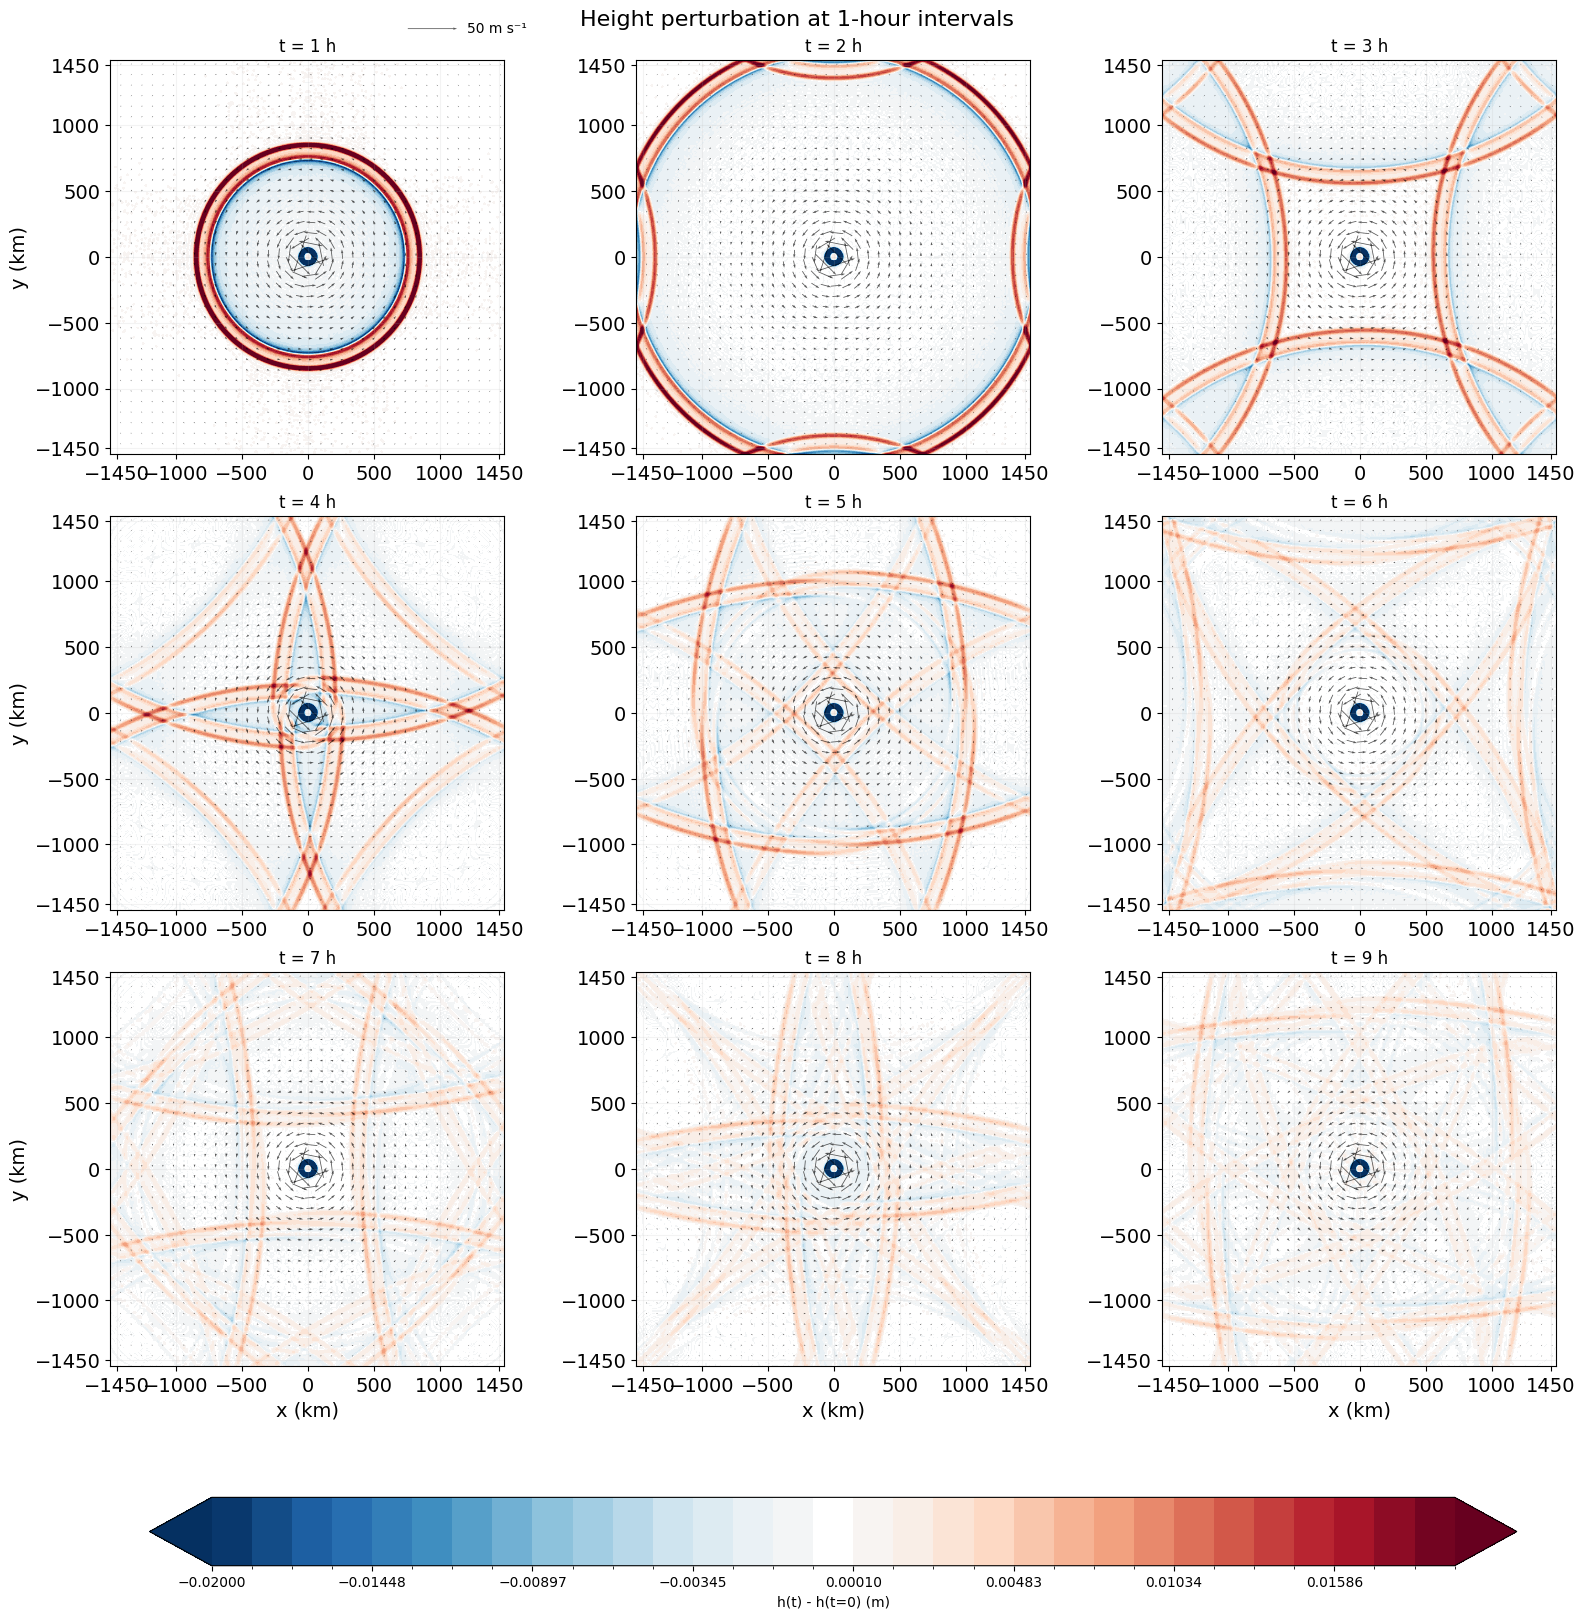

In [10]:
# Full-field panels: h(t) - h(t=0) with same-time wind vectors
# The 24 panels cover 3, 6, ..., 72 h in an 8-row by 3-column layout.
panel_hours = np.arange(1.0, 10, 1.0)

# Shading levels retain the explicit -30 to 30 limits used above.
# Replace this array if a different exact set of levels is desired.
h_levels = np.linspace(-0.02, 0.02, 30)
e = 0.0001  # Values from -e to e metres are shaded pure white.

from matplotlib.colors import BoundaryNorm, ListedColormap, Normalize

if e <= 0:
    raise ValueError("e must be a positive number.")
if h_levels[0] >= -e or h_levels[-1] <= e:
    raise ValueError("h_levels must extend below -e and above e.")

# Insert -e and e as exact boundaries, then color their interval white.
shading_levels = np.unique(np.concatenate((h_levels, [-e, e])))
level_midpoints = 0.5 * (shading_levels[:-1] + shading_levels[1:])
base_cmap = plt.get_cmap("RdBu_r")
level_colors = base_cmap(
    Normalize(vmin=h_levels[0], vmax=h_levels[-1])(level_midpoints)
)
level_colors[(level_midpoints >= -e) & (level_midpoints <= e)] = (
    1.0, 1.0, 1.0, 1.0
)
perturbation_cmap = ListedColormap(level_colors, name="RdBu_r_white_center")
perturbation_cmap.set_under(base_cmap(0.0))
perturbation_cmap.set_over(base_cmap(1.0))
perturbation_norm = BoundaryNorm(shading_levels, perturbation_cmap.N)
quiver_stride = 8  # Plot every 15th grid point in each direction.
quiver_scale = 400

snapshot_paths = sorted(snapshot_dir.glob("snapshot_*.npz"))
if not snapshot_paths:
    raise FileNotFoundError(f"Run the model first; no snapshots found in {snapshot_dir}")

# Read times from the archives so selection does not depend on filenames.
snapshot_hours = []
for path in snapshot_paths:
    with np.load(path) as snapshot:
        snapshot_hours.append(float(snapshot["t"].item()) / 3600.0)
snapshot_hours = np.asarray(snapshot_hours)

zero_index = int(np.argmin(np.abs(snapshot_hours)))
if not np.isclose(snapshot_hours[zero_index], 0.0, atol=1.0e-6):
    raise ValueError("A t=0 snapshot is required to calculate h - h_0.")

with np.load(snapshot_paths[zero_index]) as initial_snapshot:
    h_0 = initial_snapshot["h"].astype(np.float64)
    x_km = initial_snapshot["x"] / 1000.0
    y_km = initial_snapshot["y"] / 1000.0

selected_paths = []
for requested_hour in panel_hours:
    nearest_index = int(np.argmin(np.abs(snapshot_hours - requested_hour)))
    if not np.isclose(snapshot_hours[nearest_index], requested_hour, atol=1.0e-6):
        raise ValueError(
            f"No snapshot is available at t={requested_hour:g} h; "
            f"nearest time is {snapshot_hours[nearest_index]:g} h."
        )
    selected_paths.append(snapshot_paths[nearest_index])

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    #figsize=(15, 32),
    figsize=(16, 16),
    #sharex=True,
    #sharey=True,
    constrained_layout=True,
)

shading = None
reference_quiver = None
for panel_index, (ax, path, requested_hour) in enumerate(
    zip(axes.flat, selected_paths, panel_hours)
):
    with np.load(path) as snapshot:
        h_perturbation = snapshot["h"].astype(np.float64) - h_0
        h_at_time = snapshot["h"]-5000
        u_at_time = snapshot["u"]
        v_at_time = snapshot["v"]

    shading = ax.contourf(
        x_km,
        y_km,
        #h_at_time,
        h_perturbation,
        levels=shading_levels,
        cmap=perturbation_cmap,
        norm=perturbation_norm,
        extend="both",
    )
    vectors = ax.quiver(
        x_km[::quiver_stride],
        y_km[::quiver_stride],
        u_at_time[::quiver_stride, ::quiver_stride],
        v_at_time[::quiver_stride, ::quiver_stride],
        color="black",
        alpha=0.65,
        pivot="mid",
        scale=quiver_scale,
        width=0.002,
    )
    if panel_index == 0:
        reference_quiver = vectors

    ax.set_title(f"t = {requested_hour:g} h")
    ax.set_aspect("equal")
    ax.set_xticks([-1450, -1000, -500, 0, 500, 1000, 1450])
    ax.set_yticks([-1450, -1000, -500, 0, 500, 1000, 1450])
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(alpha=0.15)
    if panel_index % 3 == 0:
        ax.set_ylabel("y (km)", fontsize=14)
    if panel_index >= 6:
        ax.set_xlabel("x (km)", fontsize=14)

if reference_quiver is not None:
    axes.flat[0].quiverkey(
        reference_quiver, 0.88, 1.08, 50.0, "50 m s⁻¹", labelpos="E"
    )

colorbar = fig.colorbar(
    shading, ax=axes, orientation="horizontal", shrink=0.9, pad=0.05
)
colorbar.set_label("h(t) - h(t=0) (m)")
fig.suptitle("Height perturbation at 1-hour intervals", fontsize=16)
plt.show()